# RQ4: CLEAR against the published state of the art

Plots and tables only. Every number is read from `results/clear/`, written by
`scripts/run_study.py`; this notebook makes no LLM calls and computes no clusterings.

Two comparison settings (thesis section 3.4):

**Unmatched**: all 19 benchmarks in the default configuration, `gemini-embedding-001` + `glm-5`.
**Matched**: each benchmark on its NMI record holder's own encoder and LLM, so only the algorithm differs.

To (re)generate the underlying runs:

```
python scripts/check_ready.py
python scripts/run_study.py
```

In [1]:
import sys
from pathlib import Path
REPO = Path.cwd().parents[1]              # repo root (this notebook lives in analysis/rq4/)
sys.path.insert(0, str(REPO / 'CLEAR_algo'))

import pandas as pd
from critclust import config, plots, runners

RESULTS = REPO / 'results' / 'clear'
config.RESULTS = RESULTS
config.FIGURES = REPO / 'figures'
config.PLOTS_PNG = None
config.PUBLISHED = REPO / 'data' / 'published_results.csv'

pd.set_option('display.max_columns', 40, 'display.width', 200)

print('results:', config.RESULTS)
print('figures:', config.FIGURES)

results: /Users/louisarts/Desktop/Chattermill/LLM_clustering/results/clear
figures: /Users/louisarts/Desktop/Chattermill/LLM_clustering/figures


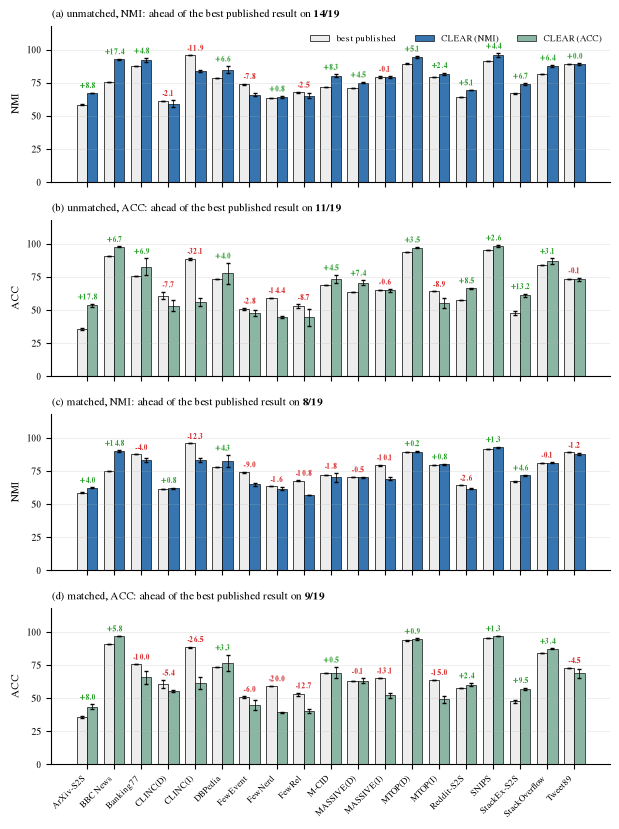

saved rq4c_C_sota_both (pdf + png)


In [2]:
# One-page version: unmatched and matched vs best published in a single
# four-panel figure (shared x, one caption in LaTeX).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from critclust import config, plots

_RC = {'font.family': 'serif', 'mathtext.fontset': 'stix',
       'font.serif': ['STIXGeneral', 'Times New Roman', 'DejaVu Serif'],
       'axes.linewidth': 0.8}
SOTA, UP, DOWN = '#ededed', '#2ca02c', '#d62728'
OURS_BY = {'NMI': '#2066a8', 'ACC': '#80ae9a'}  # coloured = ours per metric
P = pd.read_csv(config.PUBLISHED)

def best_pub(disp, met):
    d = P[(P.metric == met) & (P.benchmark == disp)]
    if d.empty:
        return np.nan, np.nan
    r = d.loc[d.value.idxmax()]
    return float(r.value), float(r['std']) if pd.notna(r['std']) else np.nan

DATA = {}
for st in ('unmatched', 'matched'):
    S = pd.read_csv(RESULTS / f'critclust_C_{st}_aligned_summary.csv')
    S['display'] = S.bench.map(lambda b: config.BENCH_DISPLAY.get(b, b))
    S = S.sort_values('display').reset_index(drop=True)
    for met in ('NMI', 'ACC'):
        S[[f'sota_{met}', f'sota_{met}_sd']] = S.display.apply(
            lambda b: pd.Series(best_pub(b, met)))
    DATA[st] = S

with plt.rc_context(_RC):
    fig, axs = plt.subplots(4, 1, figsize=(6.3, 8.4), sharex=True)
    x = np.arange(19)
    W = 0.38
    panels = [(axs[0], 'unmatched', 'NMI', 'a'), (axs[1], 'unmatched', 'ACC', 'b'),
              (axs[2], 'matched', 'NMI', 'c'), (axs[3], 'matched', 'ACC', 'd')]
    for ax, st, met, li in panels:
        S = DATA[st]
        key = met.lower()
        ours, sd = S[f'{key}_mean'], S[f'{key}_std']
        sota, ssd = S[f'sota_{met}'], S[f'sota_{met}_sd']
        delta = ours - sota
        wins = int((delta > 0).sum())
        ax.bar(x - W / 2, sota, W, color=SOTA, alpha=1.0, edgecolor='black', lw=0.5,
               label='best published')
        ax.errorbar(x - W / 2, sota, yerr=ssd.fillna(0), fmt='none',
                    ecolor='black', elinewidth=0.55, capsize=1.3, zorder=3)
        ax.bar(x + W / 2, ours, W, yerr=sd, capsize=1.3, color=OURS_BY[met], alpha=0.9,
               edgecolor='black', lw=0.5, error_kw={'elinewidth': 0.55},
               label='CLEAR')
        for i in range(len(S)):
            stop = sota[i] + (0 if pd.isna(ssd[i]) else ssd[i])
            top = max(stop, ours[i] + (sd[i] or 0))
            ax.text(i, top + 2, f'{delta[i]:+.1f}', ha='center', va='bottom',
                    fontsize=5.2, fontweight='bold',
                    color=UP if delta[i] > 0 else DOWN)
        ax.set_title(f'({li}) {st}, {met}: ahead of the best published result '
                     f'on $\\mathbf{{{wins}/19}}$', fontsize=8, loc='left')
        ax.set_ylabel(met, fontsize=8)
        ax.tick_params(axis='y', labelsize=7)
        ax.set_ylim(0, 118)
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.grid(axis='y', alpha=0.25, lw=0.6)
        for side in ('top', 'right'):
            ax.spines[side].set_visible(False)
    from matplotlib.patches import Patch
    _h = [Patch(facecolor=SOTA, alpha=1.0, edgecolor='black', lw=0.5, label='best published'),
          Patch(facecolor=OURS_BY['NMI'], alpha=0.9, edgecolor='black', lw=0.5, label='CLEAR (NMI)'),
          Patch(facecolor=OURS_BY['ACC'], alpha=0.9, edgecolor='black', lw=0.5, label='CLEAR (ACC)')]
    axs[0].legend(handles=_h, frameon=False, fontsize=6.8, loc='upper right', ncol=3)
    axs[3].set_xticks(x)
    axs[3].set_xticklabels(DATA['unmatched'].display, rotation=45, ha='right',
                           fontsize=6.5)
    plt.tight_layout()
    fig.savefig(config.FIGURES / 'rq4c_C_sota_both.pdf', bbox_inches='tight')
    plt.show()
print('saved rq4c_C_sota_both (pdf + png)')

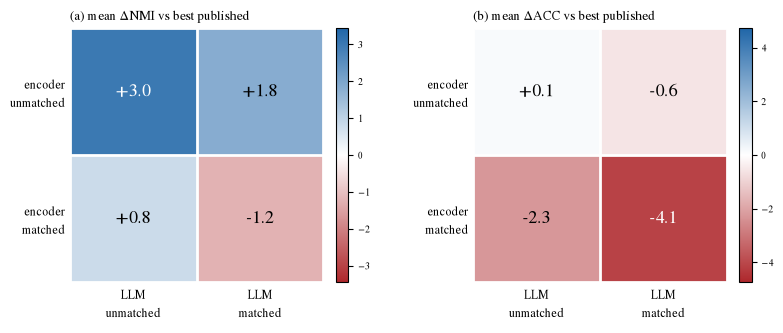

saved rq4c_factorial_delta_heat (pdf + png)


In [3]:
# Same 2x2 factorial, cells = mean delta to the best published number over the
# 19 benchmarks (positive = above SOTA on average). Diverging scale centred at 0.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from critclust import plots

_RCA = {'font.family': 'serif', 'mathtext.fontset': 'stix',
        'font.serif': ['STIXGeneral', 'Times New Roman', 'DejaVu Serif'],
        'axes.linewidth': 0.8, 'font.size': 9}
SETTINGS = ['unmatched', 'matched', 'embmatched', 'llmmatched']
CMAP = LinearSegmentedColormap.from_list('d', ['#ae282c', '#FFFFFF', '#2066a8'])

delta = {}
for st in SETTINGS:
    S = pd.read_csv(RESULTS / f'critclust_C_{st}_aligned_summary.csv')
    delta[st] = {met: (S[f'{met}_mean'] - [plots.sota_for(b, met.upper())
                                           for b in S.bench]).mean()
                 for met in ('nmi', 'acc')}

with plt.rc_context(_RCA):
    fig, axs = plt.subplots(1, 2, figsize=(8.2, 3.4), squeeze=False)
    for cidx, met in enumerate(('nmi', 'acc')):
        ax = axs[0][cidx]
        # rows: embedder unmatched / matched; cols: LLM unmatched / matched
        G = np.array([[delta['unmatched'][met], delta['llmmatched'][met]],
                      [delta['embmatched'][met], delta['matched'][met]]])
        vmax = np.abs(G).max() * 1.15
        im = ax.imshow(G, cmap=CMAP, vmin=-vmax, vmax=vmax)
        cb = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
        cb.ax.tick_params(labelsize=7)
        for (i, j), v in np.ndenumerate(G):
            ax.text(j, i, f'{v:+.1f}', ha='center', va='center', fontsize=13,
                    color='white' if abs(v) > 0.75 * vmax else 'black')
        li = chr(ord('a') + cidx)
        ax.set_title(f'({li}) mean $\\Delta${met.upper()} vs best published',
                     fontsize=9.5, loc='left')
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(['LLM\nunmatched', 'LLM\nmatched'], fontsize=8.5)
        ax.set_yticklabels(['encoder\nunmatched', 'encoder\nmatched'], fontsize=8.5)
        for sp in ax.spines.values():
            sp.set_visible(False)
        ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
        ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
        ax.grid(which='minor', color='white', lw=2)
        ax.tick_params(which='both', length=0)
    plt.tight_layout()
    fig.savefig(config.FIGURES / 'rq4c_factorial_delta_heat.pdf', bbox_inches='tight')
    plt.show()
print('saved rq4c_factorial_delta_heat (pdf + png)')

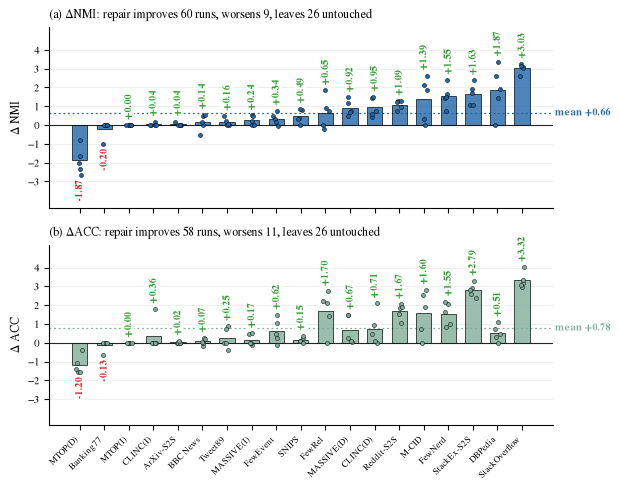

overall mean dNMI +0.66 dACC +0.78 | runs keeping >=1 round: 69 (mean +0.90/+1.08)
               dn    da
rounds_kept            
0            0.00  0.00
1            0.10  0.29
2            0.56  0.58
3            1.46  1.73
saved rq4c_C_repair_delta (pdf + png)


In [4]:
# Repair-step contribution: per-benchmark mean delta (final - judge-picked) with the
# five per-seed deltas overlaid. Zero-round seeds sit exactly on the zero line.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from critclust import config

_RC = {'font.family': 'serif', 'mathtext.fontset': 'stix',
       'font.serif': ['STIXGeneral', 'Times New Roman', 'DejaVu Serif'],
       'axes.linewidth': 0.8}
NC, AC, MEANC = '#2066a8', '#80ae9a', '#ae282c'

R = pd.read_csv(RESULTS / 'critclust_C_unmatched_aligned_runs.csv')
SEL = pd.read_csv(RESULTS / 'selector_comparison_C_unmatched.csv')
assert SEL.groupby(['bench', 'seed']).winner_match.first().all()
W = SEL[SEL.candidate == SEL.recorded_winner][['bench', 'seed', 'gold_nmi', 'gold_acc']]
M = R.merge(W, on=['bench', 'seed'])
assert len(M) == 95
M['dn'] = M.nmi - M.gold_nmi
M['da'] = M.acc - M.gold_acc
z = M[M.rounds_kept == 0]
assert z.dn.abs().max() < 1e-9 and z.da.abs().max() < 1e-9, 'zero-round runs must be unchanged'
M['display'] = M.bench.map(lambda b: config.BENCH_DISPLAY.get(b, b))
order = M.groupby('display').dn.mean().sort_values().index.tolist()

with plt.rc_context(_RC):
    fig, axs = plt.subplots(2, 1, figsize=(6.3, 5.0), sharex=True)
    x = np.arange(len(order))
    rng = np.random.RandomState(0)
    for ax, col, face, met, li in ((axs[0], 'dn', NC, 'NMI', 'a'),
                                   (axs[1], 'da', AC, 'ACC', 'b')):
        mean_b = M.groupby('display')[col].mean().reindex(order)
        ax.bar(x, mean_b, 0.62, color=face, alpha=0.8, edgecolor='black',
               lw=0.6, zorder=2)
        for i, b in enumerate(order):
            v = M.loc[M.display == b, col].to_numpy()
            ax.scatter(i + rng.uniform(-0.13, 0.13, len(v)), v, s=8.5,
                       color=face, edgecolor='black', lw=0.35, zorder=3)
        for i, b in enumerate(order):
            v = M.loc[M.display == b, col]
            mb = mean_b[b]
            up = mb >= 0
            yy = (max(v.max(), mb) + 0.28) if up else (min(v.min(), mb) - 0.28)
            ax.text(i, yy, f'{mb:+.2f}', ha='center', rotation=90,
                    va='bottom' if up else 'top', fontsize=6.8,
                    fontweight='bold', color=('#2ca02c' if up else '#d62728'), zorder=6,
                    bbox=dict(facecolor='white', edgecolor='none', pad=0.5,
                              alpha=1.0))
        gm = M[col].mean()
        ax.axhline(gm, color=face, lw=0.9, linestyle=(0, (1.5, 2.2)), zorder=1)
        ax.annotate(f'mean {gm:+.2f}', xy=(1.005, gm),
                    xycoords=('axes fraction', 'data'), va='center', ha='left',
                    fontsize=7, color=face, fontweight='bold', annotation_clip=False)
        ax.axhline(0, color='black', lw=0.8, zorder=1)
        n_up = int((M[col] > 0.005).sum())
        n_dn = int((M[col] < -0.005).sum())
        ax.set_title(f'({li}) $\\Delta${met}: repair improves {n_up} runs, '
                     f'worsens {n_dn}, leaves {95 - n_up - n_dn} untouched',
                     fontsize=8.5, loc='left')
        ax.set_ylabel(f'$\\Delta$ {met}', fontsize=8.5)
        ax.set_ylim(-4.4, 5.2)
        ax.set_yticks([-3, -2, -1, 0, 1, 2, 3, 4])
        ax.tick_params(axis='y', labelsize=7.5)
        ax.grid(axis='y', alpha=0.25, lw=0.6)
        for side in ('top', 'right'):
            ax.spines[side].set_visible(False)
    axs[1].set_xticks(x)
    axs[1].set_xticklabels(order, rotation=45, ha='right', fontsize=6.5)
    plt.tight_layout()
    fig.savefig(config.FIGURES / 'rq4c_C_repair_delta.pdf', bbox_inches='tight')
    plt.show()

k = M[M.rounds_kept > 0]
print(f'overall mean dNMI {M.dn.mean():+.2f} dACC {M.da.mean():+.2f} | '
      f'runs keeping >=1 round: {len(k)} (mean {k.dn.mean():+.2f}/{k.da.mean():+.2f})')
print(M.groupby('rounds_kept')[['dn', 'da']].mean().round(2))
print('saved rq4c_C_repair_delta (pdf + png)')
